In [ ]:
# ==========================================
# TESIS ZMVM: PM, clima y salud
# Autor: Arely Leal
# Descripción: Script en Python para generar grafico de las concentraciones diarias por año para material particulado. 
# FUNCIONA PARA PM10 (2000-2019) Y PM2.5 (2003-2019)
# ==========================================

/var/folders/8f/xcm8kn2d7csg_55l0rmqbcjc0000gn/T/ipykernel_5069/1836612309.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("no data", np.nan)


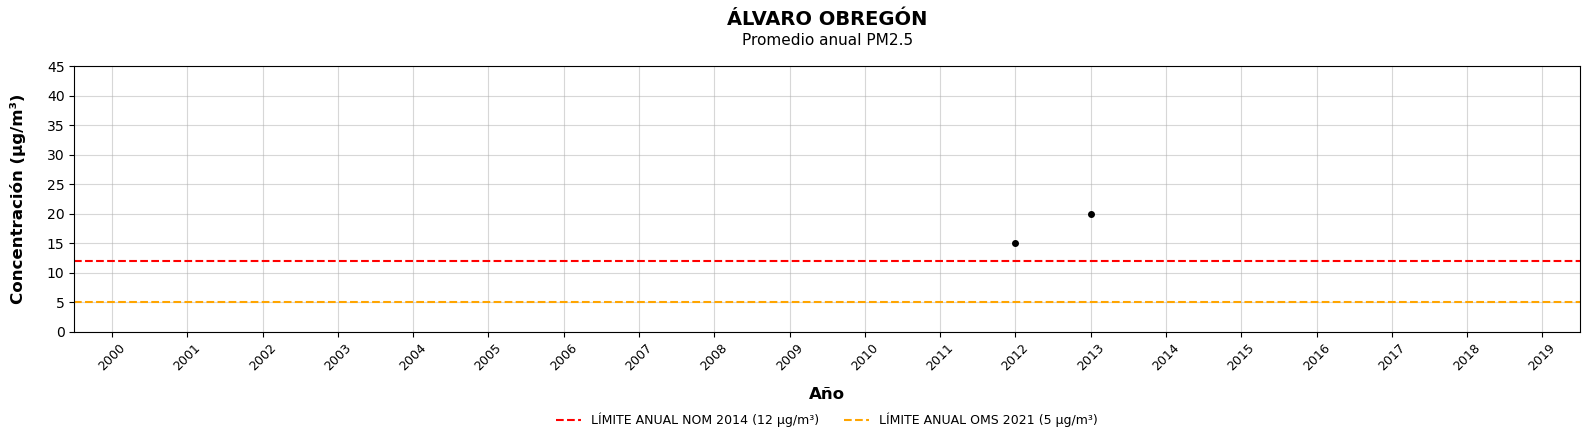

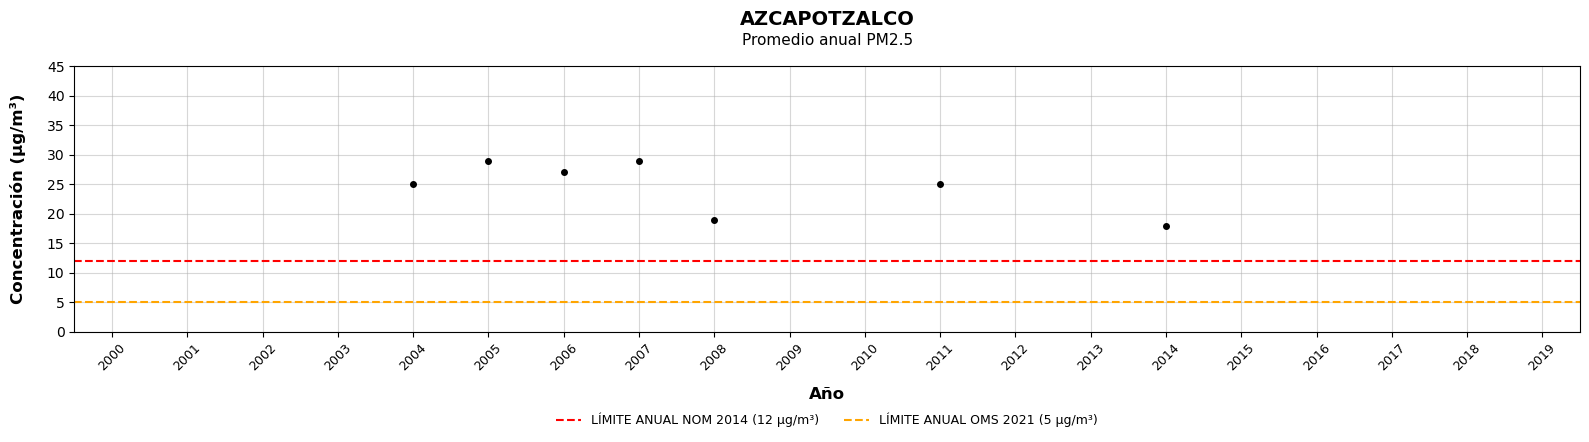

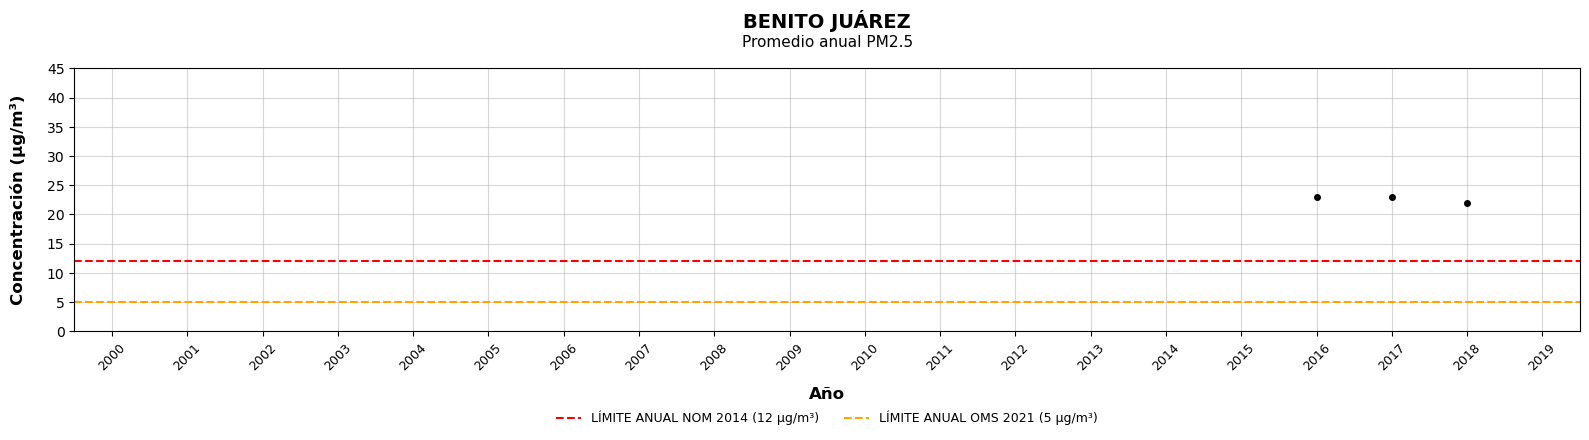

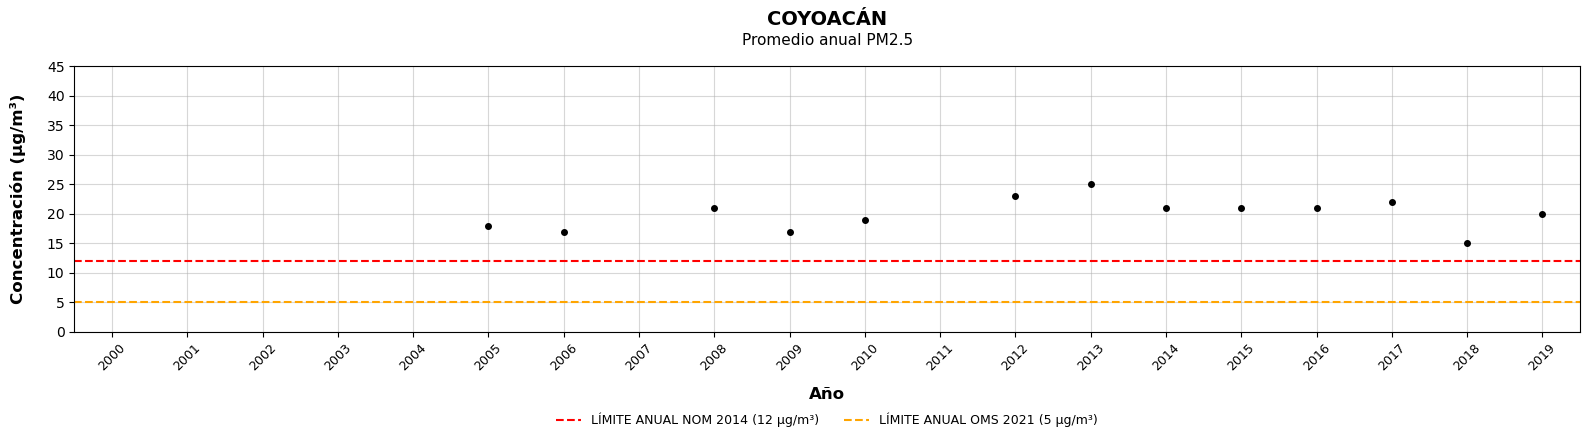

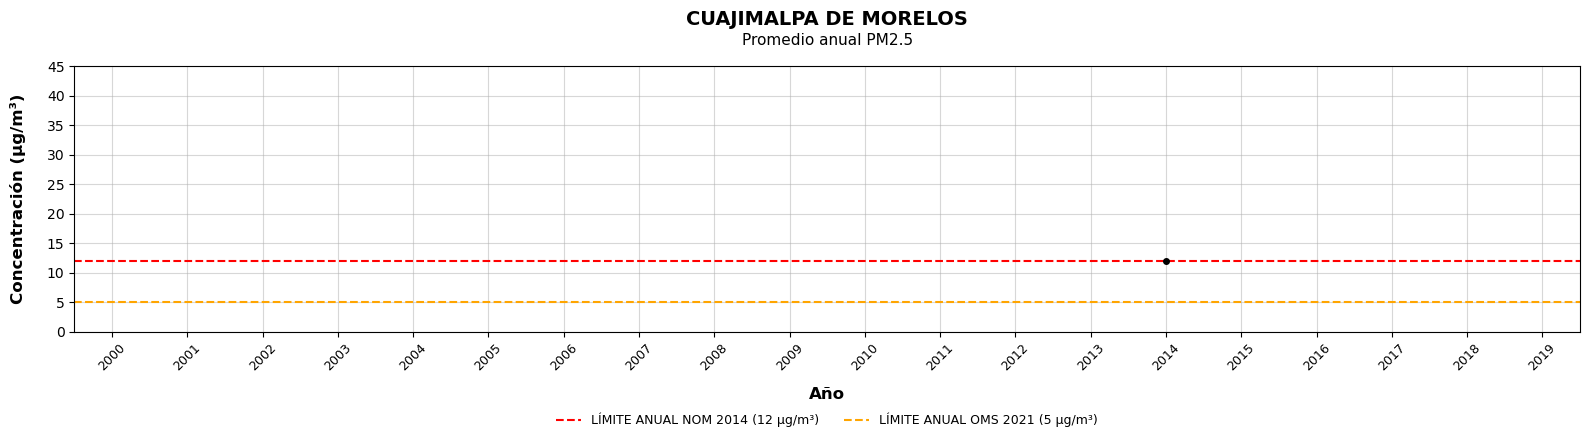

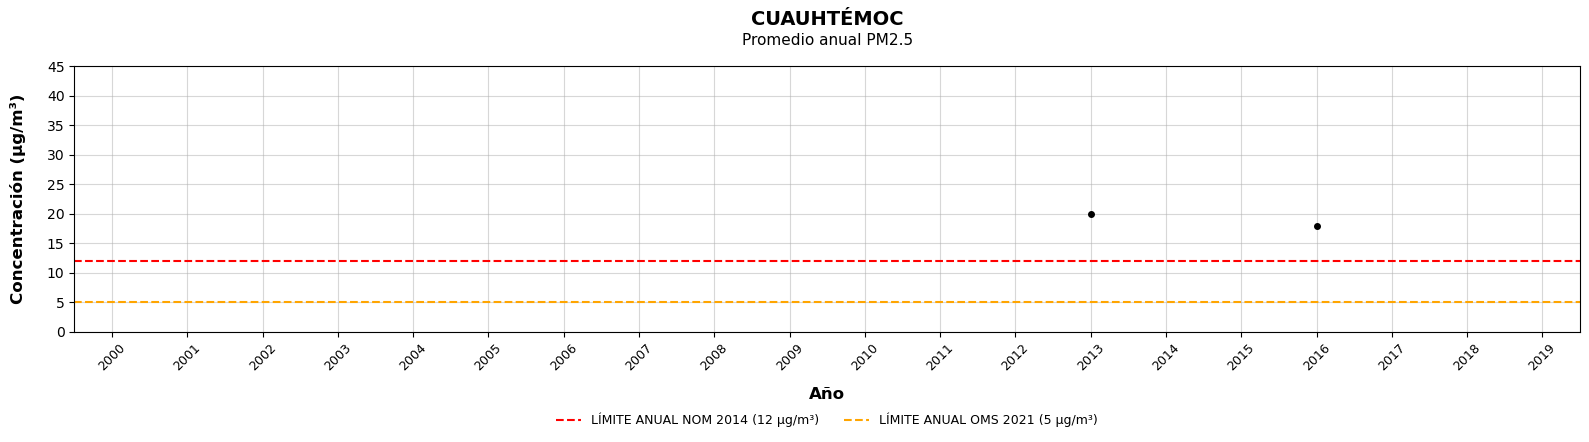

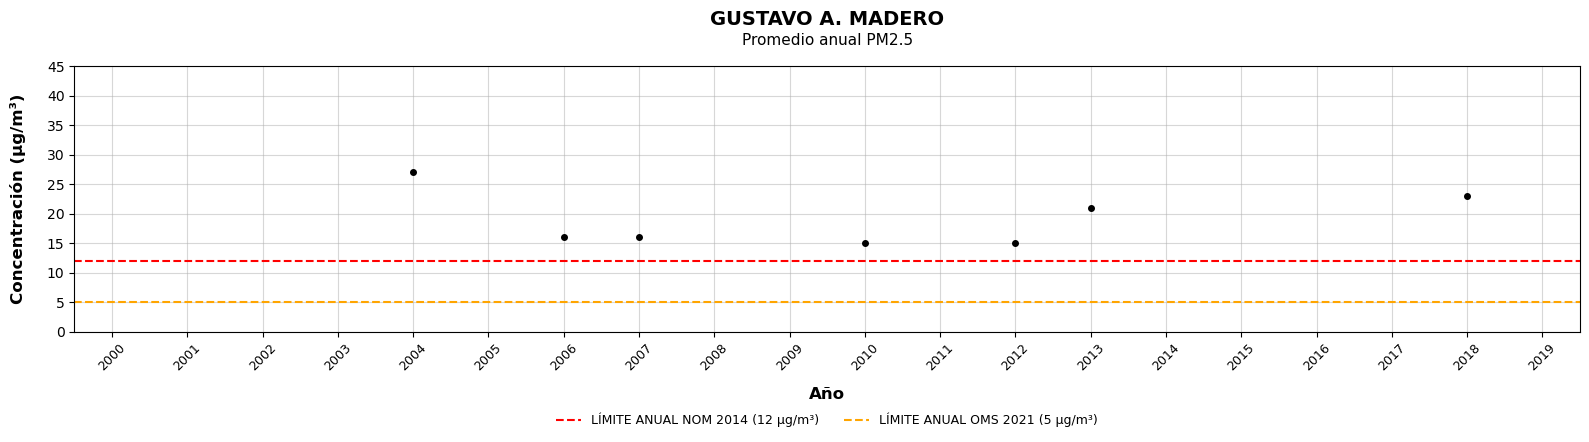

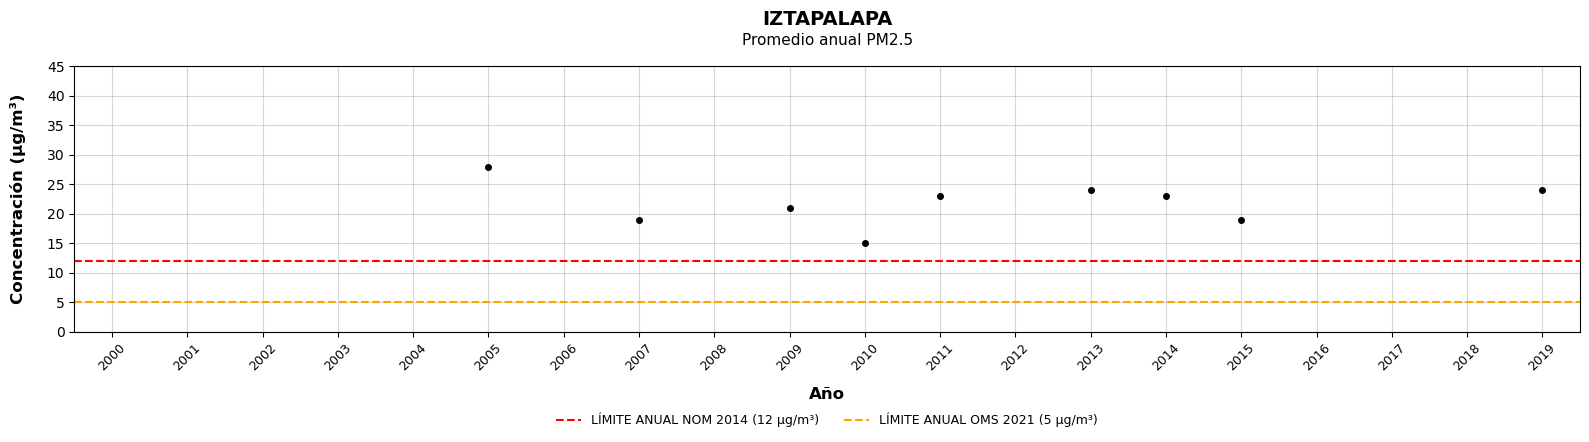

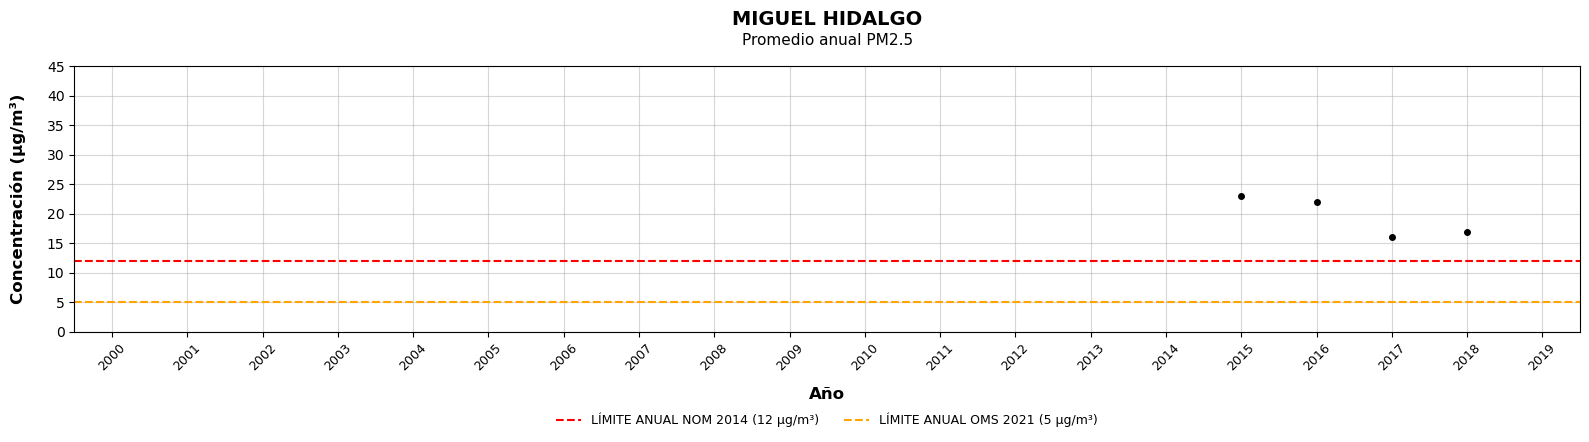

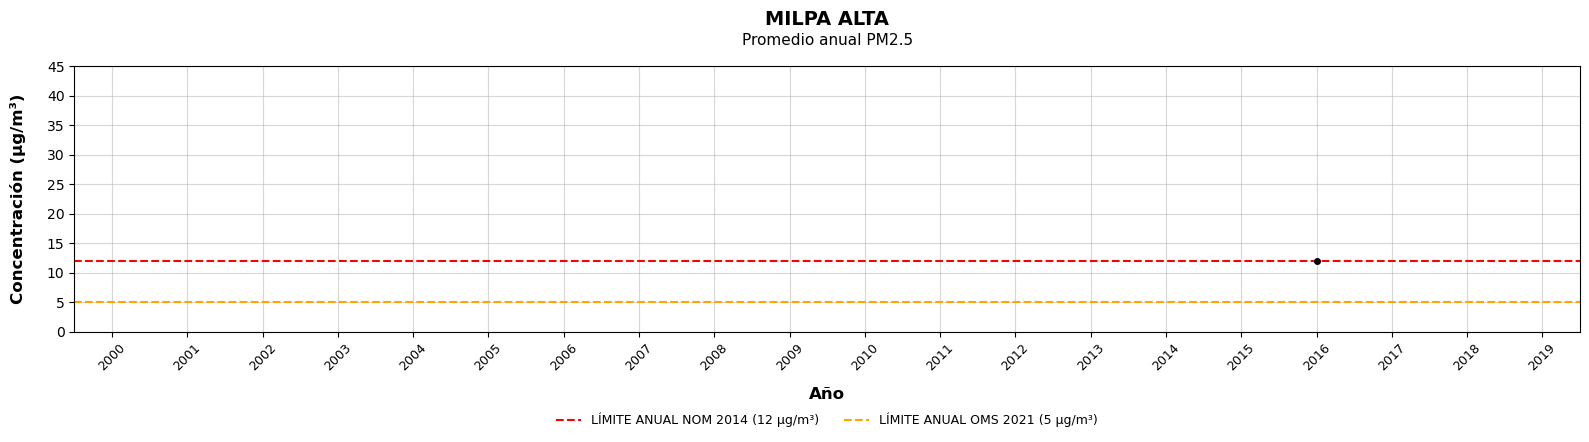

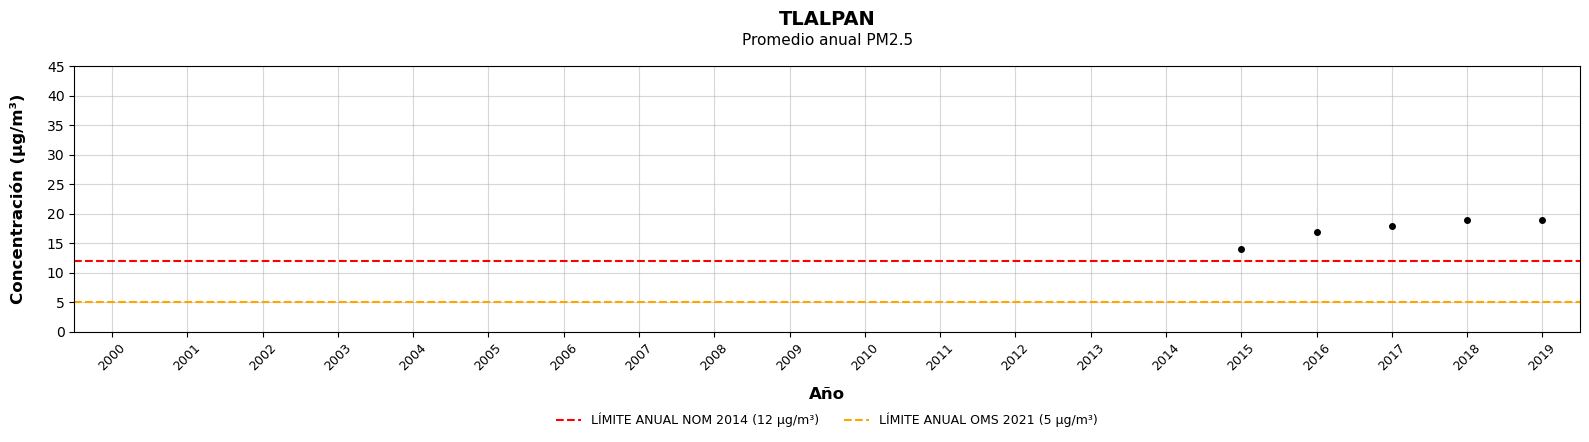

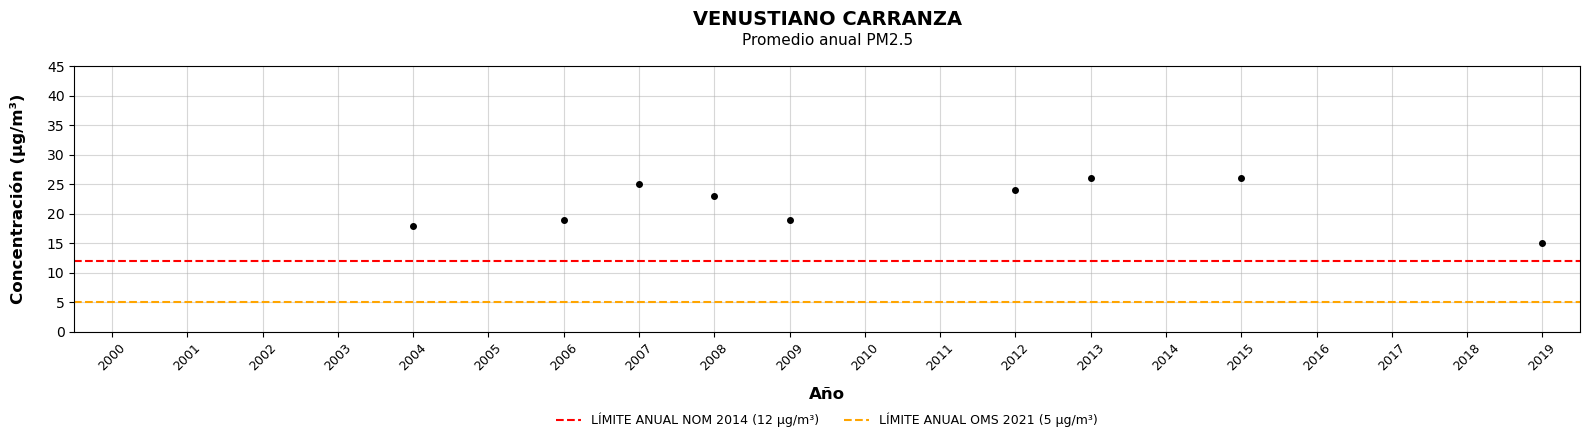

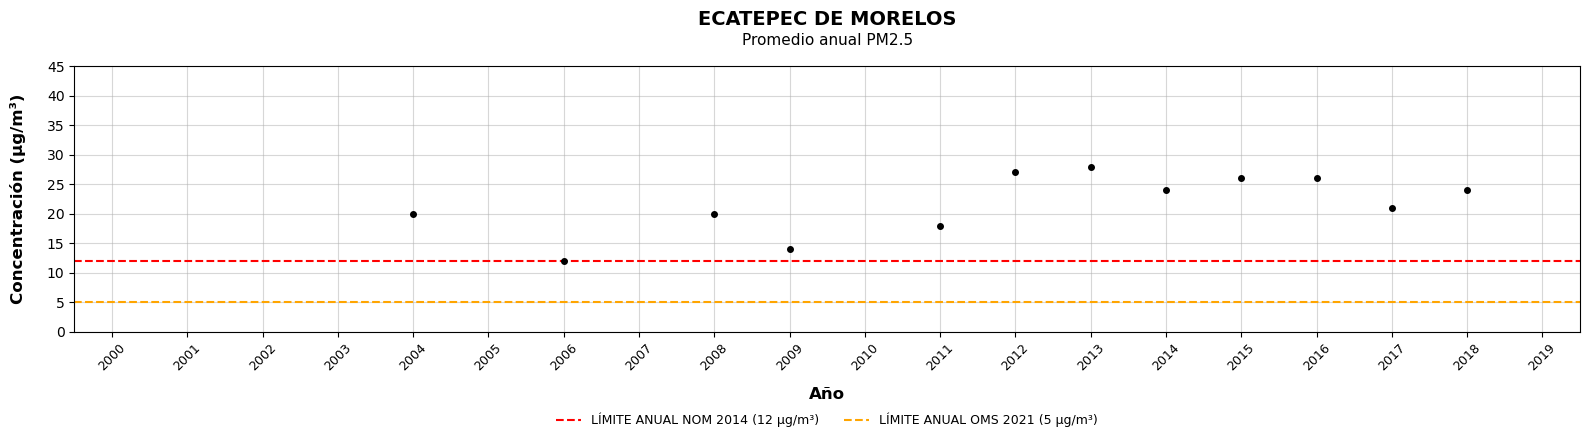

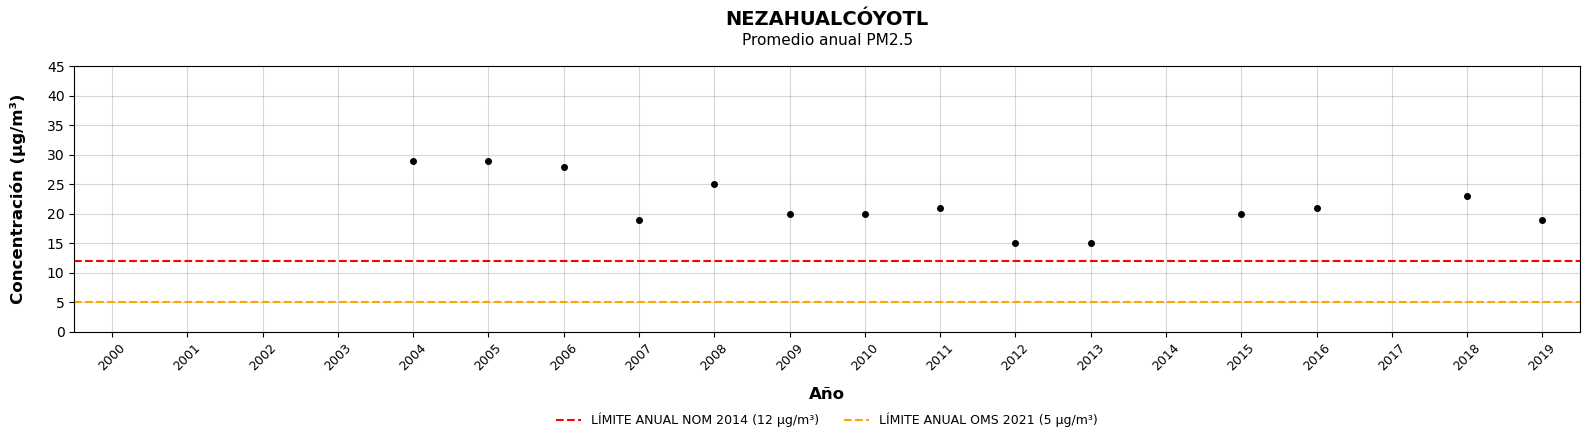

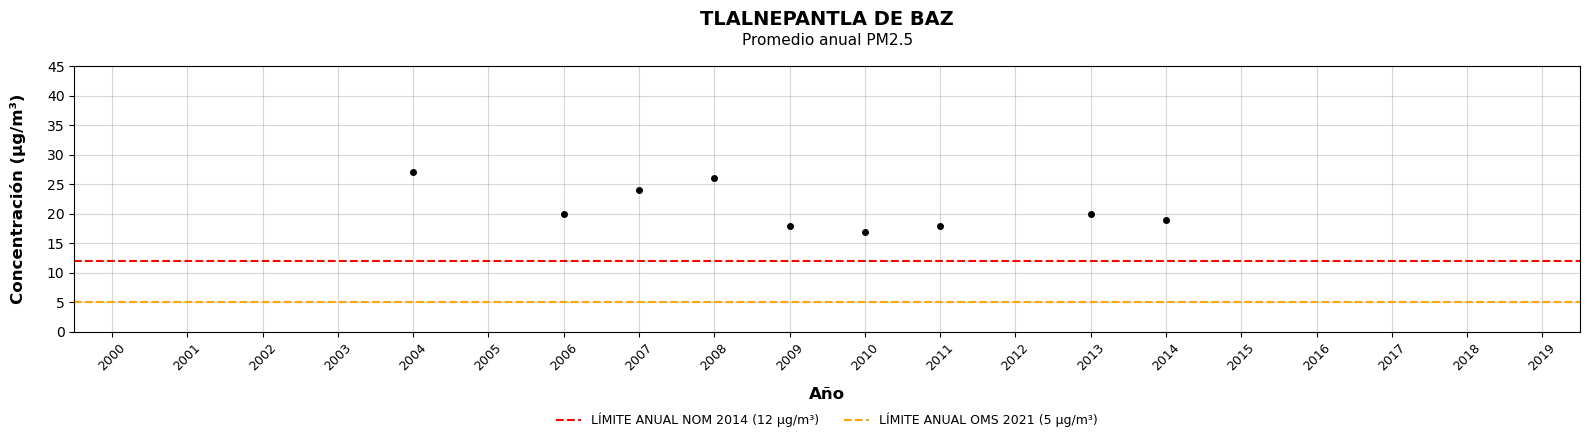

Gráficos guardados en: /Users/arelyleal/Downloads/GUARDAR_GRAFICOS


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Ruta del archivo CSV y carpeta de salida
archivo_csv = "AGREGAR RUTA DEL ARCHIVO"
ruta_salida = "AGREGAR RUTA DEL SALIDA"
os.makedirs(ruta_salida, exist_ok=True)

# =========================
# CARGAR DATOS
# =========================
df = pd.read_csv(archivo_csv)
df.columns = df.columns.str.strip()
df = df.replace("no data", np.nan)

# Convertir año a entero
df["ANO"] = pd.to_numeric(df["ANO"], errors="coerce")
df = df.dropna(subset=["ANO"])
df["ANO"] = df["ANO"].astype(int)

# Filtrar solo años 2000–2019
df = df[(df["ANO"] >= 2000) & (df["ANO"] <= 2019)]

# Dejar ANO como índice
df.set_index("ANO", inplace=True)

# Convertir resto de columnas a numérico
df = df.apply(pd.to_numeric, errors="coerce")

# Escala global para todas las gráficas
max_global = df.max().max()
ylim_superior = max(45, max_global * 1.2)

# =========================
# GRAFICAR
# =========================
for delegacion in df.columns:
    df_delegacion = df[[delegacion]].dropna().copy()
    if df_delegacion.empty:
        continue

    df_delegacion = df_delegacion.rename(columns={delegacion: "PM..."})

    plt.figure(figsize=(16, 6))
    ax = plt.gca()

    # Puntos
    ax.plot(
        df_delegacion.index,
        df_delegacion["PM..."],
        'ko',
        markersize=4,
        zorder=3
    )

    # Líneas de referencia: cambiar en funcion de PM10 o PM2.5
    ax.axhline(
        12, color='red', linestyle='--', linewidth=1.5,
        label="LÍMITE ANUAL NOM 2014 (12 µg/m³)"
    )
    ax.axhline(
        5, color='orange', linestyle='--', linewidth=1.5,
        label="LÍMITE ANUAL OMS 2021 (5 µg/m³)"
    )

    # Título principal
    ax.text(
        0.5, 1.14,
        delegacion.upper(),
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold'
    )

    # Subtítulo
    ax.text(
        0.5, 1.07,
        "Promedio anual PM...",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=11
    )

    # Etiquetas
    ax.set_xlabel("Año", fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel("Concentración (µg/m³)", fontsize=12, fontweight='bold', labelpad=15)

    # Cuadrícula
    ax.grid(True, alpha=0.5)

    # Leyenda
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, -0.40),
        ncol=2,
        frameon=False,
        fontsize=9
    )

    # Escalas iguales
    ax.set_ylim(0, ylim_superior)

    # Margen simétrico real
    ax.set_xlim(1999.5, 2019.5)

    # Ticks exactos
    ax.set_xticks(range(2000, 2020))
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # Guardar
    nombre_archivo = f"{delegacion.replace(' ', '_').upper()}.png"
    ruta_completa = os.path.join(ruta_salida, nombre_archivo)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(ruta_completa, dpi=300, bbox_inches="tight")
    plt.show()

print(f"Gráficos guardados en: {ruta_salida}")